In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# ======================
# 1) دیتاست MNIST
# ======================
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
testset  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)


# ======================
# 2) مدل CNN ساده با پارامتر نوع Pooling
# ======================
class SimpleCNN(nn.Module):
    def __init__(self, pooling_type="max"):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)

        if pooling_type == "max":
            self.pool = nn.MaxPool2d(2, 2)
        elif pooling_type == "avg":
            self.pool = nn.AvgPool2d(2, 2)
        elif pooling_type == "sum":
            # SumPooling = AvgPooling * (kernel_size*kernel_size)
            self.pool = nn.AvgPool2d(2, 2)
            self.is_sum = True
        else:
            raise ValueError("pooling_type must be max, avg or sum")

        self.fc1 = nn.Linear(8 * 14 * 14, 10)
        self.pooling_type = pooling_type

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        if getattr(self, "is_sum", False):  # SumPooling trick
            x = x * (2 * 2)  # چون kernel=2, پس مساحت=4
        x = x.view(-1, 8 * 14 * 14)
        x = self.fc1(x)
        return x


# ======================
# 3) تابع آموزش + تست
# ======================
def train_and_eval(pooling_type):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net = SimpleCNN(pooling_type=pooling_type).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)

    # --- Train ---
    for epoch in range(1):  # فقط یک Epoch برای سریع بودن
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # --- Test ---
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Pooling={pooling_type.upper():5s} -> Test Accuracy: {acc:.2f}%")
    return acc


# ======================
# 4) اجرای هر سه Pooling
# ======================
for pooling in ["max", "avg", "sum"]:
    train_and_eval(pooling)


100.0%
100.0%
100.0%
100.0%


Pooling=MAX   -> Test Accuracy: 94.63%
Pooling=AVG   -> Test Accuracy: 92.56%
Pooling=SUM   -> Test Accuracy: 96.23%


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np

# ======================
# 0) ثابت کردن seed
# ======================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(0)   # <-- اینجا قبل از ساخت dataset, dataloader, model

# ======================
# 1) دیتاست MNIST
# ======================
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
testset  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# ======================
# 2) پیاده‌سازی Poolingهای جدید
# ======================
class SumPool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.pool = nn.AvgPool2d(kernel_size, stride)
        self.scale = kernel_size * kernel_size
    def forward(self, x):
        return self.pool(x) * self.scale

class MinPool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
    def forward(self, x):
        return -F.max_pool2d(-x, self.kernel_size, self.stride)

class MedianPool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
    def forward(self, x):
        unfold = F.unfold(x, kernel_size=self.kernel_size, stride=self.stride)
        B, Ck2, L = unfold.shape
        k2 = self.kernel_size * self.kernel_size
        unfold = unfold.view(B, x.shape[1], k2, L)   # (B, C, k*k, L)
        med = unfold.median(dim=2).values            # (B, C, L)
        H_out = (x.shape[2] - self.kernel_size)//self.stride + 1
        W_out = (x.shape[3] - self.kernel_size)//self.stride + 1
        return med.view(B, x.shape[1], H_out, W_out)

class ModePool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
    def forward(self, x):
        unfold = F.unfold(x, kernel_size=self.kernel_size, stride=self.stride)
        B, Ck2, L = unfold.shape
        k2 = self.kernel_size * self.kernel_size
        unfold = unfold.view(B, x.shape[1], k2, L)   # (B, C, k*k, L)
        mode_vals, _ = torch.mode(unfold, dim=2)     # (B, C, L)
        H_out = (x.shape[2] - self.kernel_size)//self.stride + 1
        W_out = (x.shape[3] - self.kernel_size)//self.stride + 1
        return mode_vals.view(B, x.shape[1], H_out, W_out)

class LpPool2d(nn.Module):
    def __init__(self, p=2, kernel_size=2, stride=2):
        super().__init__()
        self.p = p
        self.kernel_size = kernel_size
        self.stride = stride
    def forward(self, x):
        unfold = F.unfold(x, kernel_size=self.kernel_size, stride=self.stride)
        B, Ck2, L = unfold.shape
        k2 = self.kernel_size * self.kernel_size
        unfold = unfold.view(B, x.shape[1], k2, L)   # (B, C, k*k, L)
        lp = unfold.abs().pow(self.p).sum(dim=2).pow(1/self.p)  # (B, C, L)
        H_out = (x.shape[2] - self.kernel_size)//self.stride + 1
        W_out = (x.shape[3] - self.kernel_size)//self.stride + 1
        return lp.view(B, x.shape[1], H_out, W_out)

# ======================
# 3) مدل CNN ساده با Pooling دلخواه
# ======================
class SimpleCNN(nn.Module):
    def __init__(self, pooling_type="max"):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)

        if pooling_type == "max":
            self.pool = nn.MaxPool2d(2, 2)
        elif pooling_type == "avg":
            self.pool = nn.AvgPool2d(2, 2)
        elif pooling_type == "sum":
            self.pool = SumPool2d(2, 2)
        elif pooling_type == "min":
            self.pool = MinPool2d(2, 2)
        elif pooling_type == "median":
            self.pool = MedianPool2d(2, 2)
        elif pooling_type == "mode":
            self.pool = ModePool2d(2, 2)
        elif pooling_type == "lp":
            self.pool = LpPool2d(p=2, kernel_size=2, stride=2)
        else:
            raise ValueError("pooling_type must be one of: max, avg, sum, min, median, mode, lp")

        self.fc1 = nn.Linear(8 * 14 * 14, 10)
        self.pooling_type = pooling_type

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(-1, 8 * 14 * 14)
        x = self.fc1(x)
        return x

# ======================
# 4) تابع آموزش + تست
# ======================
def train_and_eval(pooling_type):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net = SimpleCNN(pooling_type=pooling_type).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)

    for epoch in range(1):  # فقط 1 ایپاک برای تست سریع
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Pooling={pooling_type.upper():7s} -> Test Accuracy: {acc:.2f}%")
    return acc

# ======================
# 5) اجرای همه مدل‌ها
# ======================
for pooling in ["max", "avg", "sum", "min", "median", "mode", "lp"]:
    train_and_eval(pooling)


Pooling=MAX     -> Test Accuracy: 94.27%
Pooling=AVG     -> Test Accuracy: 92.20%
Pooling=SUM     -> Test Accuracy: 93.25%
Pooling=MIN     -> Test Accuracy: 92.67%
Pooling=MEDIAN  -> Test Accuracy: 92.56%
Pooling=MODE    -> Test Accuracy: 91.89%
Pooling=LP      -> Test Accuracy: 94.45%



Training with pooling: max
[MAX] Epoch 1/10 | Train Acc: 93.71% | Val Acc: 97.59%
[MAX] Epoch 2/10 | Train Acc: 97.06% | Val Acc: 98.79%
[MAX] Epoch 3/10 | Train Acc: 97.52% | Val Acc: 98.84%
[MAX] Epoch 4/10 | Train Acc: 97.75% | Val Acc: 98.78%
[MAX] Epoch 5/10 | Train Acc: 98.04% | Val Acc: 98.89%
[MAX] Epoch 6/10 | Train Acc: 98.22% | Val Acc: 99.08%
[MAX] Epoch 7/10 | Train Acc: 98.34% | Val Acc: 98.96%
[MAX] Epoch 8/10 | Train Acc: 98.37% | Val Acc: 99.12%
[MAX] Epoch 9/10 | Train Acc: 98.46% | Val Acc: 99.06%
[MAX] Epoch 10/10 | Train Acc: 98.49% | Val Acc: 99.19%

>>> [MAX] Best Val Acc: 99.19% | Final Acc: 99.19%

Classification Report:
              precision    recall  f1-score   support

           0     0.9909    0.9980    0.9944       980
           1     0.9947    0.9947    0.9947      1135
           2     0.9941    0.9855    0.9898      1032
           3     0.9940    0.9911    0.9926      1010
           4     0.9939    0.9919    0.9929       982
           5     0.9

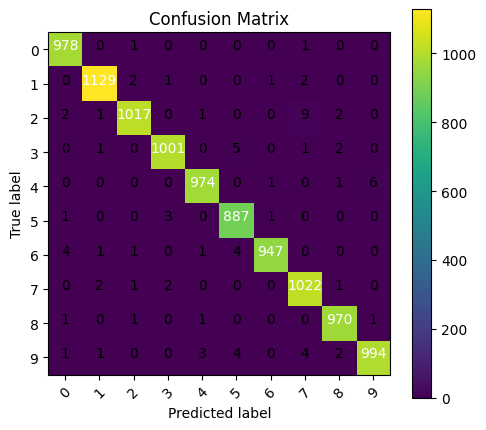

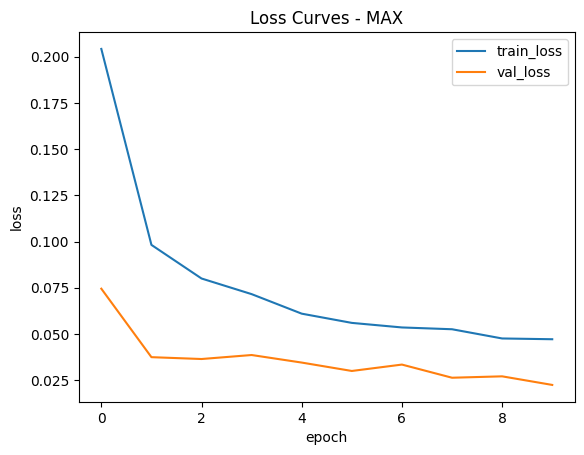

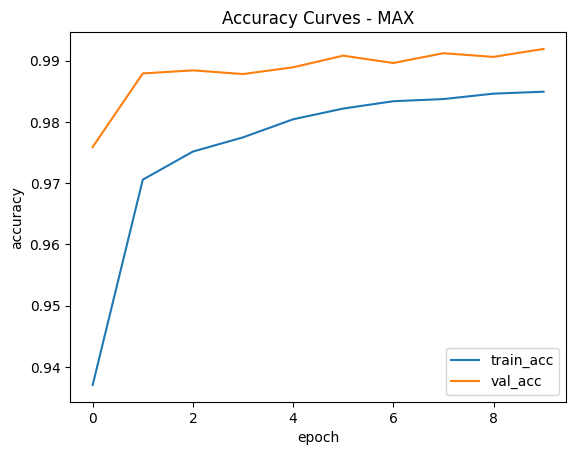


Training with pooling: avg
[AVG] Epoch 1/10 | Train Acc: 93.95% | Val Acc: 97.76%
[AVG] Epoch 2/10 | Train Acc: 97.27% | Val Acc: 98.81%
[AVG] Epoch 3/10 | Train Acc: 97.63% | Val Acc: 98.68%
[AVG] Epoch 4/10 | Train Acc: 97.92% | Val Acc: 98.99%
[AVG] Epoch 5/10 | Train Acc: 98.15% | Val Acc: 99.08%
[AVG] Epoch 6/10 | Train Acc: 98.16% | Val Acc: 99.07%
[AVG] Epoch 7/10 | Train Acc: 98.41% | Val Acc: 98.98%
[AVG] Epoch 8/10 | Train Acc: 98.77% | Val Acc: 99.32%
[AVG] Epoch 9/10 | Train Acc: 98.73% | Val Acc: 99.35%
[AVG] Epoch 10/10 | Train Acc: 98.80% | Val Acc: 99.29%

>>> [AVG] Best Val Acc: 99.35% | Final Acc: 99.35%

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.9980    0.9985       980
           1     0.9973    0.9947    0.9960      1135
           2     0.9932    0.9981    0.9957      1032
           3     0.9882    0.9960    0.9921      1010
           4     0.9939    0.9878    0.9908       982
           5     0.9

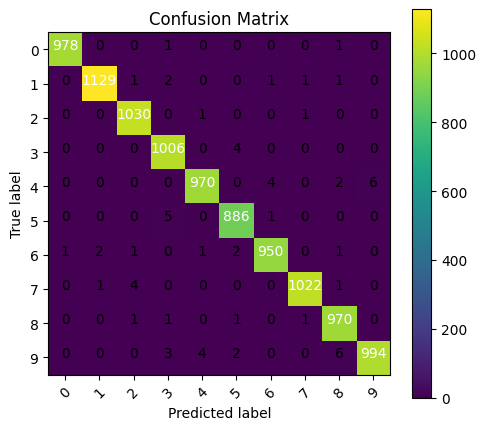

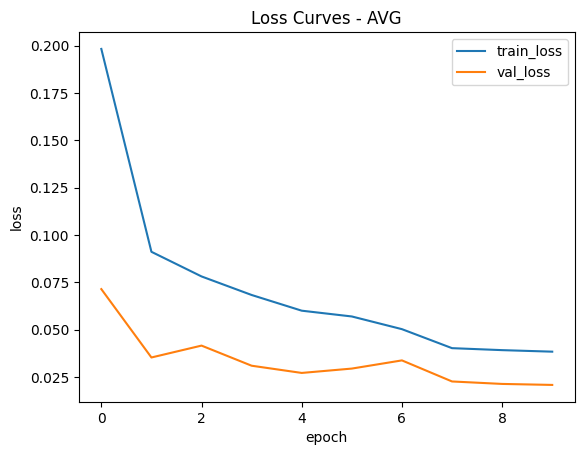

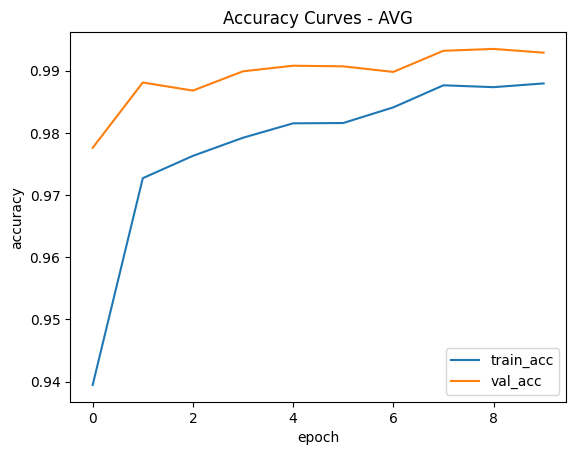


Training with pooling: sum
[SUM] Epoch 1/10 | Train Acc: 93.80% | Val Acc: 98.02%
[SUM] Epoch 2/10 | Train Acc: 97.10% | Val Acc: 98.86%
[SUM] Epoch 3/10 | Train Acc: 97.60% | Val Acc: 98.84%
[SUM] Epoch 4/10 | Train Acc: 97.87% | Val Acc: 98.78%
[SUM] Epoch 5/10 | Train Acc: 98.43% | Val Acc: 99.05%
[SUM] Epoch 6/10 | Train Acc: 98.50% | Val Acc: 99.18%
[SUM] Epoch 7/10 | Train Acc: 98.53% | Val Acc: 99.36%
[SUM] Epoch 8/10 | Train Acc: 98.50% | Val Acc: 99.34%
[SUM] Epoch 9/10 | Train Acc: 98.64% | Val Acc: 99.37%
[SUM] Epoch 10/10 | Train Acc: 98.60% | Val Acc: 99.28%

>>> [SUM] Best Val Acc: 99.37% | Final Acc: 99.37%

Classification Report:
              precision    recall  f1-score   support

           0     0.9969    0.9929    0.9949       980
           1     0.9956    0.9965    0.9960      1135
           2     0.9923    0.9932    0.9927      1032
           3     0.9951    0.9960    0.9955      1010
           4     0.9949    0.9919    0.9934       982
           5     0.9

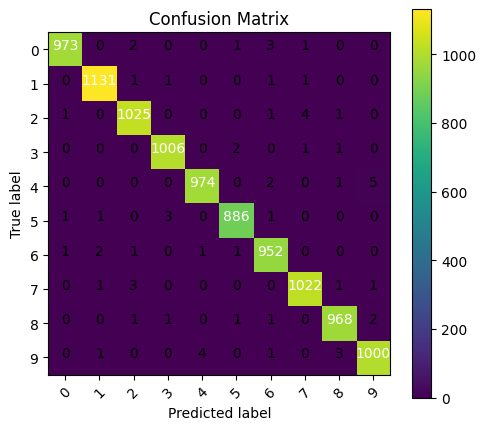

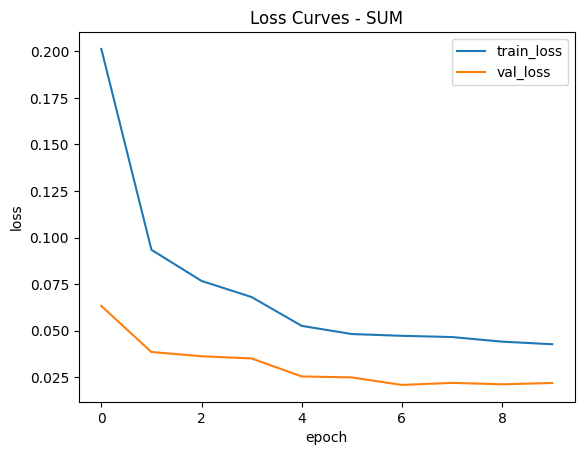

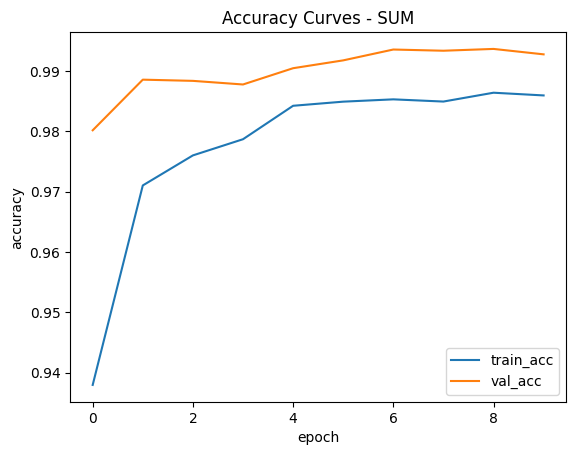


Training with pooling: min
[MIN] Epoch 1/10 | Train Acc: 91.90% | Val Acc: 98.22%
[MIN] Epoch 2/10 | Train Acc: 96.31% | Val Acc: 98.08%
[MIN] Epoch 3/10 | Train Acc: 97.07% | Val Acc: 98.62%
[MIN] Epoch 4/10 | Train Acc: 97.30% | Val Acc: 98.29%
[MIN] Epoch 5/10 | Train Acc: 97.38% | Val Acc: 98.66%
[MIN] Epoch 6/10 | Train Acc: 97.69% | Val Acc: 98.82%
[MIN] Epoch 7/10 | Train Acc: 97.80% | Val Acc: 98.87%
[MIN] Epoch 8/10 | Train Acc: 97.85% | Val Acc: 98.93%
[MIN] Epoch 9/10 | Train Acc: 98.03% | Val Acc: 99.18%
[MIN] Epoch 10/10 | Train Acc: 98.06% | Val Acc: 99.09%

>>> [MIN] Best Val Acc: 99.18% | Final Acc: 99.18%

Classification Report:
              precision    recall  f1-score   support

           0     0.9969    0.9949    0.9959       980
           1     0.9956    0.9965    0.9960      1135
           2     0.9951    0.9864    0.9908      1032
           3     0.9940    0.9921    0.9931      1010
           4     0.9949    0.9837    0.9892       982
           5     0.9

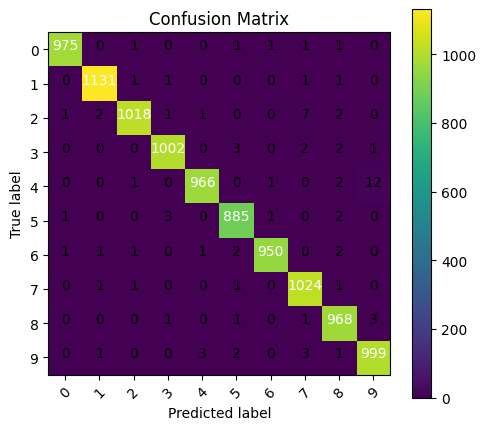

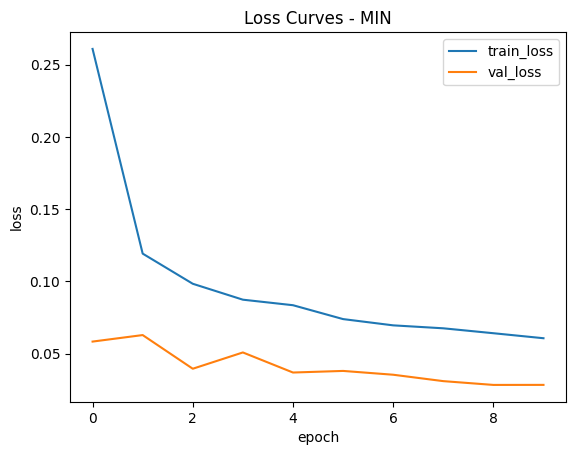

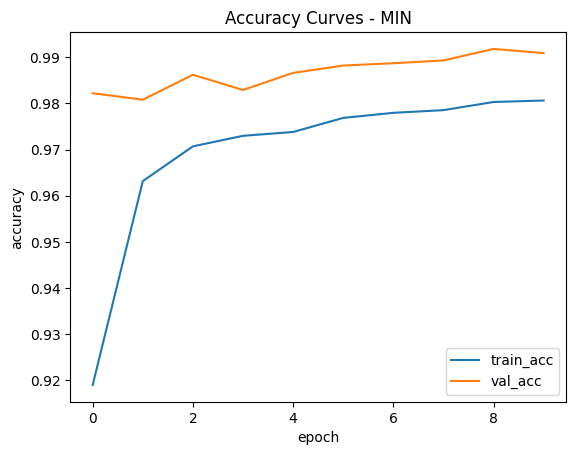


Training with pooling: median
[MEDIAN] Epoch 1/10 | Train Acc: 92.54% | Val Acc: 96.90%
[MEDIAN] Epoch 2/10 | Train Acc: 96.38% | Val Acc: 98.39%
[MEDIAN] Epoch 3/10 | Train Acc: 97.11% | Val Acc: 98.42%
[MEDIAN] Epoch 4/10 | Train Acc: 97.42% | Val Acc: 98.65%
[MEDIAN] Epoch 5/10 | Train Acc: 97.69% | Val Acc: 98.87%
[MEDIAN] Epoch 6/10 | Train Acc: 97.70% | Val Acc: 98.99%
[MEDIAN] Epoch 7/10 | Train Acc: 97.92% | Val Acc: 98.79%
[MEDIAN] Epoch 8/10 | Train Acc: 98.00% | Val Acc: 99.13%
[MEDIAN] Epoch 9/10 | Train Acc: 98.12% | Val Acc: 99.07%
[MEDIAN] Epoch 10/10 | Train Acc: 98.26% | Val Acc: 98.98%

>>> [MEDIAN] Best Val Acc: 99.13% | Final Acc: 99.13%

Classification Report:
              precision    recall  f1-score   support

           0     0.9949    0.9969    0.9959       980
           1     0.9947    0.9938    0.9943      1135
           2     0.9961    0.9922    0.9942      1032
           3     0.9911    0.9941    0.9926      1010
           4     0.9959    0.9817    0

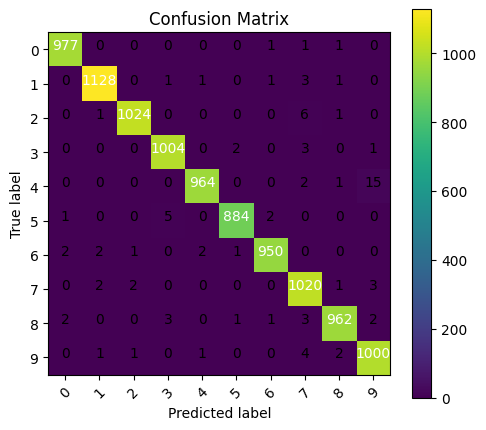

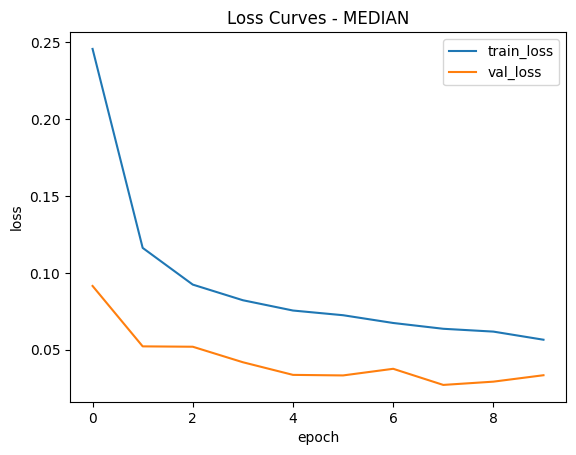

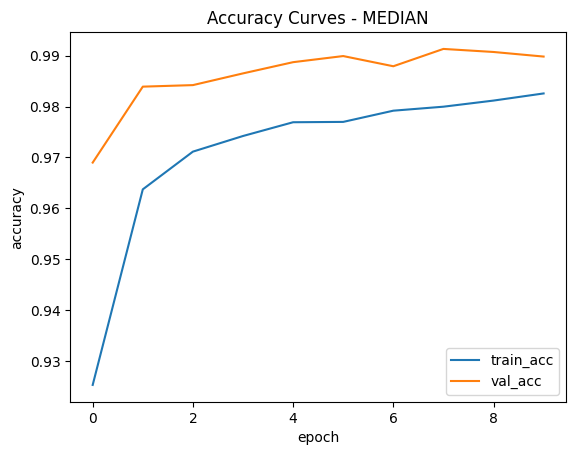


Training with pooling: mode
[MODE] Epoch 1/10 | Train Acc: 91.46% | Val Acc: 98.14%
[MODE] Epoch 2/10 | Train Acc: 96.22% | Val Acc: 98.34%
[MODE] Epoch 3/10 | Train Acc: 96.70% | Val Acc: 98.30%
[MODE] Epoch 4/10 | Train Acc: 97.13% | Val Acc: 98.54%
[MODE] Epoch 5/10 | Train Acc: 97.28% | Val Acc: 98.80%
[MODE] Epoch 6/10 | Train Acc: 97.54% | Val Acc: 98.87%
[MODE] Epoch 7/10 | Train Acc: 97.72% | Val Acc: 98.89%
[MODE] Epoch 8/10 | Train Acc: 97.83% | Val Acc: 98.91%
[MODE] Epoch 9/10 | Train Acc: 97.87% | Val Acc: 98.96%
[MODE] Epoch 10/10 | Train Acc: 97.97% | Val Acc: 98.95%

>>> [MODE] Best Val Acc: 98.96% | Final Acc: 98.96%

Classification Report:
              precision    recall  f1-score   support

           0     0.9949    0.9949    0.9949       980
           1     0.9887    0.9982    0.9934      1135
           2     0.9856    0.9952    0.9904      1032
           3     0.9901    0.9941    0.9921      1010
           4     0.9948    0.9776    0.9861       982
        

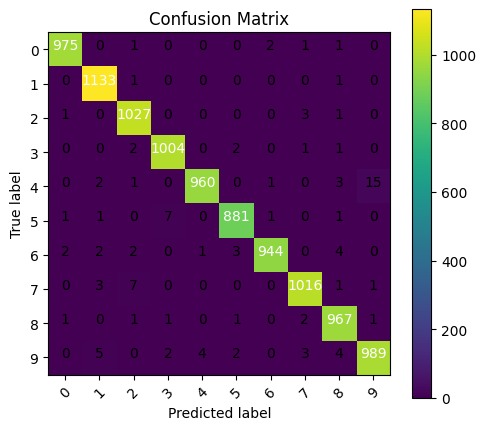

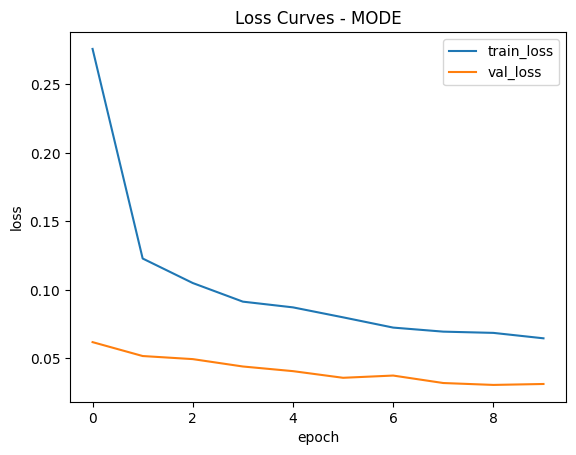

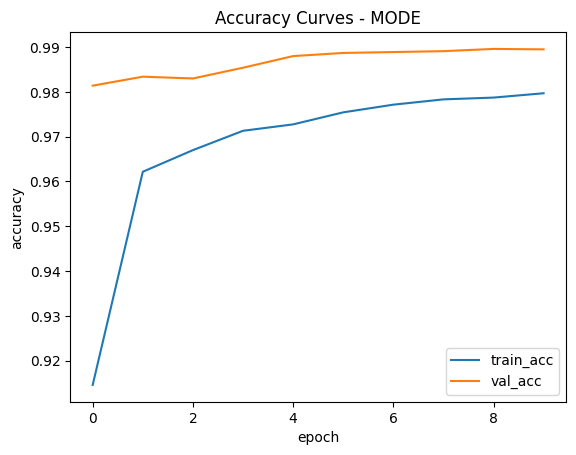


Training with pooling: lp
[LP] Epoch 1/10 | Train Acc: 93.71% | Val Acc: 98.29%
[LP] Epoch 2/10 | Train Acc: 97.03% | Val Acc: 98.62%
[LP] Epoch 3/10 | Train Acc: 97.69% | Val Acc: 98.61%
[LP] Epoch 4/10 | Train Acc: 97.95% | Val Acc: 99.01%
[LP] Epoch 5/10 | Train Acc: 98.07% | Val Acc: 99.09%
[LP] Epoch 6/10 | Train Acc: 98.28% | Val Acc: 99.11%
[LP] Epoch 7/10 | Train Acc: 98.35% | Val Acc: 99.00%
[LP] Epoch 8/10 | Train Acc: 98.33% | Val Acc: 99.10%
[LP] Epoch 9/10 | Train Acc: 98.72% | Val Acc: 99.44%
[LP] Epoch 10/10 | Train Acc: 98.75% | Val Acc: 99.24%

>>> [LP] Best Val Acc: 99.44% | Final Acc: 99.44%

Classification Report:
              precision    recall  f1-score   support

           0     0.9969    0.9969    0.9969       980
           1     0.9974    0.9982    0.9978      1135
           2     0.9961    0.9903    0.9932      1032
           3     0.9980    0.9950    0.9965      1010
           4     0.9939    0.9949    0.9944       982
           5     0.9911    0.996

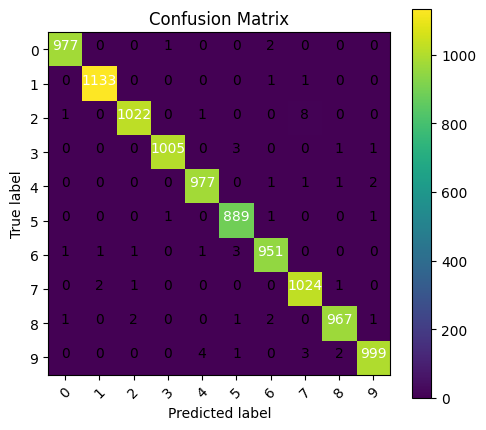

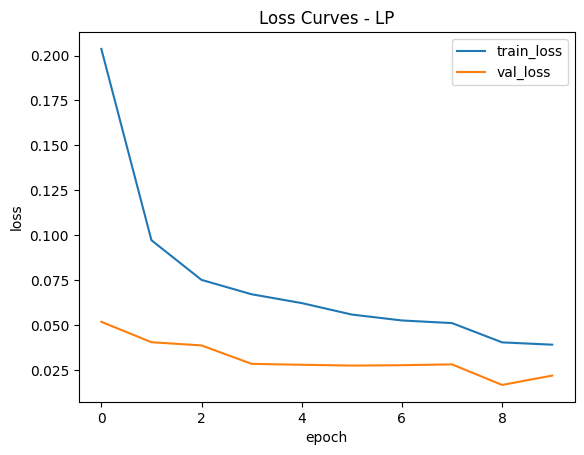

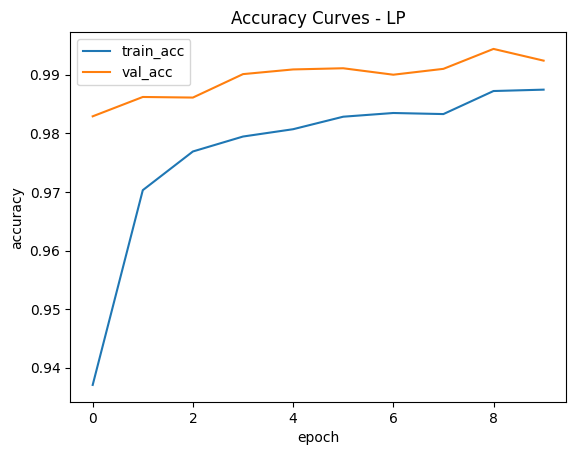


===== Summary (Final Test Accuracy) =====
max    : 99.19%
avg    : 99.35%
sum    : 99.37%
min    : 99.18%
median : 99.13%
mode   : 98.96%
lp     : 99.44%


In [10]:
# ======================
# Imports
# ======================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict

# ======================
# 0) ثابت کردن seed
# ======================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(0)

# ======================
# CONFIG ثابت
# ======================
CONFIG = {
    "batch_size": 128,
    "epochs": 10,
    "lr": 0.001,
    "weight_decay": 1e-4,
    "dropout": 0.25,
    "augment": True,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "kernel_size": 2,
    "stride": 2
}

# ======================
# 1) دیتاست MNIST + Augmentation
# ======================
if CONFIG["augment"]:
    transform_train = transforms.Compose([
        transforms.RandomRotation(8, fill=(0,)),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), fill=0),
        transforms.ToTensor()
    ])
else:
    transform_train = transforms.Compose([transforms.ToTensor()])

transform_test = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform_train)
testset  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform_test)

g = torch.Generator()
g.manual_seed(0)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=CONFIG["batch_size"], shuffle=True, generator=g)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=CONFIG["batch_size"], shuffle=False)

# ======================
# 2) Poolingهای جدید
# ======================
class SumPool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.pool = nn.AvgPool2d(kernel_size, stride)
        self.scale = kernel_size * kernel_size
    def forward(self, x):
        return self.pool(x) * self.scale

class MinPool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
    def forward(self, x):
        return -F.max_pool2d(-x, self.kernel_size, self.stride)

class MedianPool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
    def forward(self, x):
        unfold = F.unfold(x, kernel_size=self.kernel_size, stride=self.stride)
        B, Ck2, L = unfold.shape
        k2 = self.kernel_size * self.kernel_size
        C = x.shape[1]
        unfold = unfold.view(B, C, k2, L)
        med = unfold.median(dim=2).values
        H_out = (x.shape[2] - self.kernel_size)//self.stride + 1
        W_out = (x.shape[3] - self.kernel_size)//self.stride + 1
        return med.view(B, C, H_out, W_out)

class ModePool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
    def forward(self, x):
        unfold = F.unfold(x, kernel_size=self.kernel_size, stride=self.stride)
        B, Ck2, L = unfold.shape
        k2 = self.kernel_size * self.kernel_size
        C = x.shape[1]
        unfold = unfold.view(B, C, k2, L)
        mode_vals, _ = torch.mode(unfold, dim=2)
        H_out = (x.shape[2] - self.kernel_size)//self.stride + 1
        W_out = (x.shape[3] - self.kernel_size)//self.stride + 1
        return mode_vals.view(B, C, H_out, W_out)

class LpPool2d(nn.Module):
    def __init__(self, p=2, kernel_size=2, stride=2):
        super().__init__()
        self.p = p
        self.kernel_size = kernel_size
        self.stride = stride
    def forward(self, x):
        unfold = F.unfold(x, kernel_size=self.kernel_size, stride=self.stride)
        B, Ck2, L = unfold.shape
        k2 = self.kernel_size * self.kernel_size
        C = x.shape[1]
        unfold = unfold.view(B, C, k2, L)
        lp = unfold.abs().pow(self.p).sum(dim=2).pow(1/self.p)
        H_out = (x.shape[2] - self.kernel_size)//self.stride + 1
        W_out = (x.shape[3] - self.kernel_size)//self.stride + 1
        return lp.view(B, C, H_out, W_out)

# ======================
# 3) مدل CNN با Pooling دلخواه
# ======================
class SimpleCNN(nn.Module):
    def __init__(self, pooling_type="max"):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        if pooling_type == "max":
            self.pool = nn.MaxPool2d(CONFIG["kernel_size"], CONFIG["stride"])
        elif pooling_type == "avg":
            self.pool = nn.AvgPool2d(CONFIG["kernel_size"], CONFIG["stride"])
        elif pooling_type == "sum":
            self.pool = SumPool2d(CONFIG["kernel_size"], CONFIG["stride"])
        elif pooling_type == "min":
            self.pool = MinPool2d(CONFIG["kernel_size"], CONFIG["stride"])
        elif pooling_type == "median":
            self.pool = MedianPool2d(CONFIG["kernel_size"], CONFIG["stride"])
        elif pooling_type == "mode":
            self.pool = ModePool2d(CONFIG["kernel_size"], CONFIG["stride"])
        elif pooling_type == "lp":
            self.pool = LpPool2d(p=2, kernel_size=CONFIG["kernel_size"], stride=CONFIG["stride"])
        else:
            raise ValueError("Invalid pooling type")

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.drop = nn.Dropout(CONFIG["dropout"])
        self.fc1 = nn.Linear(32*14*14, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

# ======================
# 4) آموزش و ارزیابی + نمودار و جدول
# ======================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, running_correct, total = 0.0,0,0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*labels.size(0)
        _, preds = outputs.max(1)
        running_correct += (preds==labels).sum().item()
        total += labels.size(0)
    return running_loss/total, running_correct/total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct, total = 0.0,0,0
    all_preds, all_labels = [],[]
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()*labels.size(0)
        _, preds = outputs.max(1)
        running_correct += (preds==labels).sum().item()
        total += labels.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return running_loss/total, running_correct/total, all_preds, all_labels

def plot_confusion(cm, classes):
    plt.figure(figsize=(5,4.5))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt='d'
    thresh = cm.max()/2.
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
                 horizontalalignment="center",
                 color="white" if cm[i,j]>thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

def train_and_eval_pooling(pooling_type):
    device = CONFIG["device"]
    model = SimpleCNN(pooling_type).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

    history = defaultdict(list)
    best_acc = 0.0
    best_state = None

    for epoch in range(1, CONFIG["epochs"]+1):
        train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, testloader, criterion, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        scheduler.step(val_acc)
        print(f"[{pooling_type.upper()}] Epoch {epoch}/{CONFIG['epochs']} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")
        if val_acc>best_acc:
            best_acc=val_acc
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict({k:v.to(device) for k,v in best_state.items()})

    val_loss, val_acc, preds, labels = evaluate(model, testloader, criterion, device)
    print(f"\n>>> [{pooling_type.upper()}] Best Val Acc: {best_acc*100:.2f}% | Final Acc: {val_acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(labels, preds, digits=4))

    cm = confusion_matrix(labels, preds)
    plot_confusion(cm, classes=[str(i) for i in range(10)])

    plt.figure()
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title(f"Loss Curves - {pooling_type.upper()}")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.title(f"Accuracy Curves - {pooling_type.upper()}")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.show()

    return val_acc

# ======================
# 5) اجرای همه Poolingها و جدول نهایی
# ======================
results = {}
for pooling in ["max", "avg", "sum", "min", "median", "mode", "lp"]:
    print("\n"+"="*60)
    print(f"Training with pooling: {pooling}")
    print("="*60)
    acc = train_and_eval_pooling(pooling)
    results[pooling]=acc

print("\n===== Summary (Final Test Accuracy) =====")
for k,v in results.items():
    print(f"{k:7s}: {v*100:.2f}%")
